# Graficar rápido — datos del medidor (formato `medicionNN`)

Carga una medición (carpeta `Datos/medicionNN`), concatena en orden sus chunks
`medicionNN_nnnn.txt` (tab-separated, columnas **`t_s, x_mm, y_mm`**) y grafica
**x(t)** e **y(t)**. Más abajo: estimación rápida del **período** por máximos.

In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# >>> Elegí la medición a graficar (carpeta dentro de Datos) <<<
CARPETA = os.path.join("Datos", "medicion00")

# Metadatos de la medición (mm/px, resolución, umbral, fecha, ...)
meta = {}
_metas = glob.glob(os.path.join(CARPETA, "*_meta.txt"))
if _metas:
    with open(_metas[0]) as fh:
        for line in fh:
            line = line.strip()
            if "\t" in line and not line.startswith("#"):
                k, v = line.split("\t", 1)
                meta[k] = v
print("medición:", os.path.basename(CARPETA))
for k, v in meta.items():
    print(f"  {k}: {v}")

medición: medicion00
  fecha: 2026-05-29T18:00:40
  mm_por_px: 0.1302083333
  width_px: 1920
  height_px: 1080
  umbral: 0.08
  guardar_cada_s: 60
  columnas: t_s	x_mm	y_mm


In [2]:
# Chunks de datos, ordenados por su índice nnnn (NO alfabético). Excluye el _meta.
archivos = glob.glob(os.path.join(CARPETA, "*_[0-9][0-9][0-9][0-9].txt"))
archivos.sort(key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
print(f"{len(archivos)} archivos encontrados")
print(archivos[:3], "...", archivos[-3:])

5 archivos encontrados
['Datos\\medicion00\\medicion00_0000.txt', 'Datos\\medicion00\\medicion00_0001.txt', 'Datos\\medicion00\\medicion00_0002.txt'] ... ['Datos\\medicion00\\medicion00_0002.txt', 'Datos\\medicion00\\medicion00_0003.txt', 'Datos\\medicion00\\medicion00_0004.txt']


In [3]:
# Concatena todos los chunks en orden -> curva completa
datos = []
for f in archivos:
    a = np.atleast_2d(np.loadtxt(f, delimiter="\t"))
    if a.size:                      # ignora chunks vacíos
        datos.append(a)
datos = np.concatenate(datos, axis=0)
print("shape:", datos.shape, "(filas, columnas)")
datos[:5]

shape: (3632, 3) (filas, columnas)


array([[6.66670000e-02, 1.74169800e+02, 7.25106510e+01],
       [1.33333000e-01, 1.74169800e+02, 7.25106510e+01],
       [2.00000000e-01, 1.72670395e+02, 7.24224780e+01],
       [2.66667000e-01, 1.71894989e+02, 7.24141240e+01],
       [3.33333000e-01, 1.71894989e+02, 7.24141240e+01]])

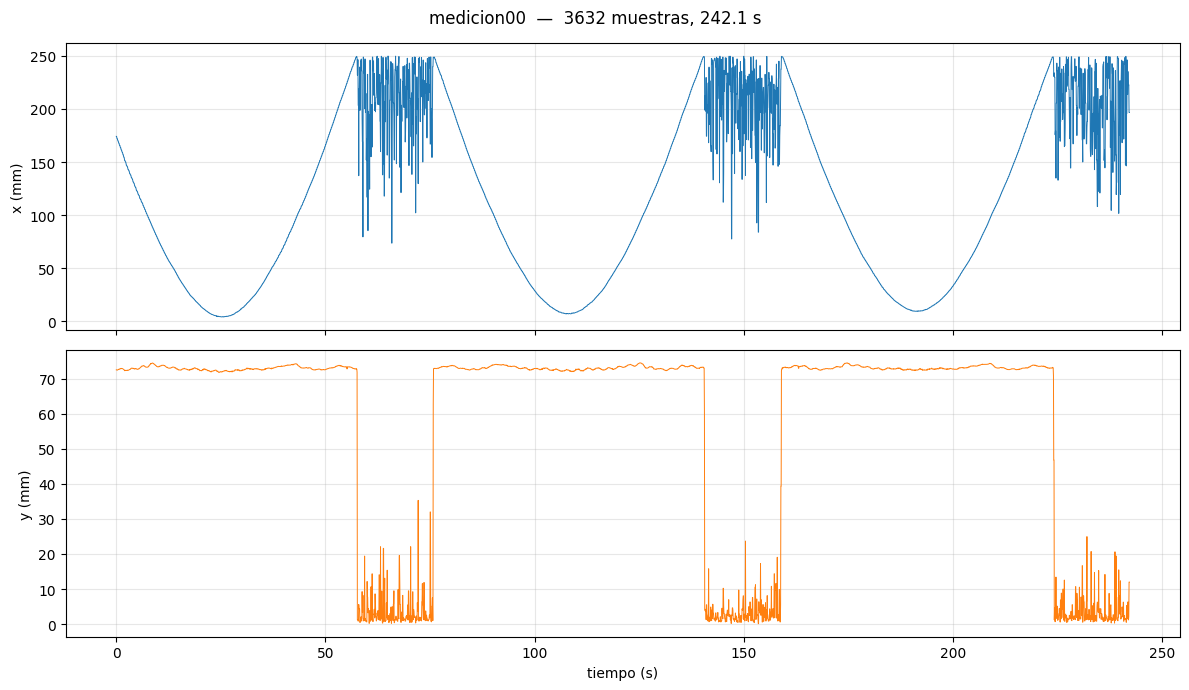

In [4]:
t    = datos[:, 0]   # tiempo (s)
x_mm = datos[:, 1]   # posición X (mm)
y_mm = datos[:, 2]   # posición Y (mm)

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(t, x_mm, lw=0.7)
axs[0].set_ylabel("x (mm)")
axs[0].grid(alpha=0.3)
axs[1].plot(t, y_mm, lw=0.7, color="tab:orange")
axs[1].set_ylabel("y (mm)")
axs[1].set_xlabel("tiempo (s)")
axs[1].grid(alpha=0.3)
fig.suptitle(f"{os.path.basename(CARPETA)}  —  {len(t)} muestras, {t[-1]:.1f} s")
plt.tight_layout()
plt.show()

In [8]:
# Período: definí intervalos (t_min, t_max) donde haya UN máximo claro de x(t).
# Ajustá estos valores mirando el gráfico de arriba.
senal = x_mm     # eje a analizar (X es el relevante para Cavendish)

intervalos = [
    (0,  50),
    (100, 120),
    (180, 200),
]

picos = []
for tmin, tmax in intervalos:
    mask = (t >= tmin) & (t <= tmax)
    if not mask.any():
        print(f"  (intervalo {tmin}-{tmax}s vacío, lo salto)")
        continue
    idx_local = np.argmin(senal[mask])
    picos.append(int(np.where(mask)[0][idx_local]))

picos = np.array(picos)
print("tiempos de los mínimos:", t[picos])
print("valores (mm):", senal[picos])

tiempos de los mínimos: [ 25.666667 108.066667 191.2     ]
valores (mm): [4.250098 7.126206 9.45281 ]


In [9]:
t_picos = t[picos]
diffs = np.diff(t_picos)
T = diffs.mean()

print(f"Tiempos de los máximos: {t_picos}")
print(f"Distancias entre picos: {diffs}")
print(f"Período estimado T = {T:.4f} s  (std = {diffs.std():.4f} s)")

Tiempos de los máximos: [ 25.666667 108.066667 191.2     ]
Distancias entre picos: [82.4      83.133333]
Período estimado T = 82.7667 s  (std = 0.3667 s)


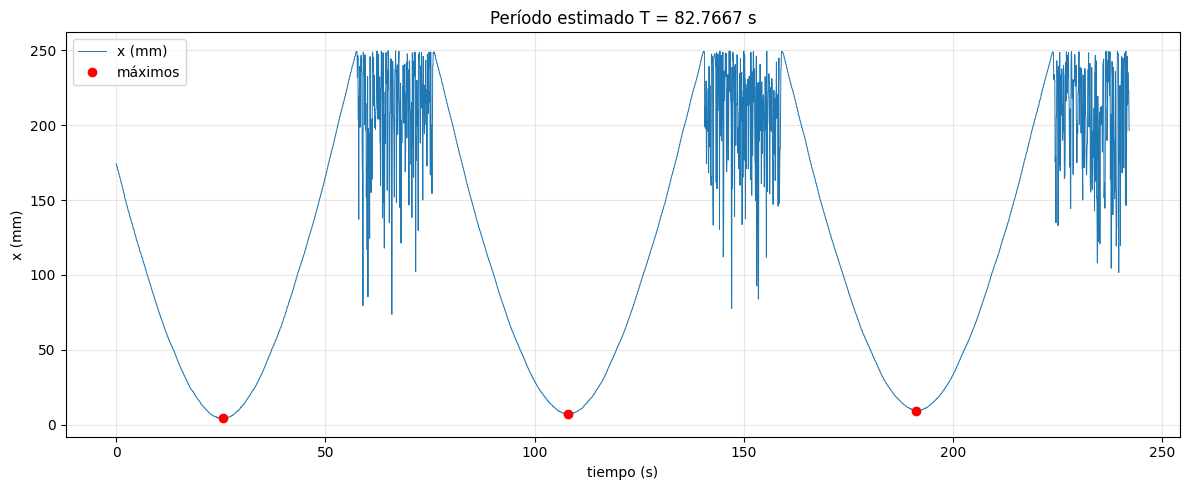

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(t, senal, lw=0.7, label="x (mm)")
plt.plot(t_picos, senal[picos], "o", color="red", label="máximos")
plt.xlabel("tiempo (s)")
plt.ylabel("x (mm)")
plt.title(f"Período estimado T = {T:.4f} s")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()